# Clasificación de Neumonía con PneumoniaMNIST usando Keras

## Descripción del Proyecto

En este notebook desarrollaremos un modelo de **Deep Learning** para clasificar imágenes de rayos X de tórax y detectar **neumonía**. Utilizaremos el dataset **PneumoniaMNIST**, que forma parte de la colección MedMNIST.

### Sobre el Dataset

- **PneumoniaMNIST** contiene imágenes de rayos X pediátricos de tórax
- Las imágenes están redimensionadas a **28x28 píxeles** en escala de grises
- **Clasificación binaria**: Normal (0) vs Neumonía (1)
- Fuente original: Chest X-Ray Images (Kermany et al., 2018)

In [ ]:
#!pip install tensorflow -q
#!pip install scikit-learn -q
#!pip install matplotlib -q
#!pip install seaborn -q


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 1. Configuración del Entorno e Importación de Librerías

In [2]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

2026-01-09 18:31:55.621900: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/luciaderulos/.pyenv/versions/3.11.7/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## 2. Carga y Exploración del Dataset

In [ ]:
# MedMNIST dataset
import medmnist
from medmnist import PneumoniaMNIST

In [ ]:
# TensorFlow y Keras
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Métricas de evaluación
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc,
    precision_recall_curve
)

In [7]:
# Configuración de reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
print(f"TensorFlow version: {tf.__version__}")
print(f"MedMNIST version: {medmnist.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.2
MedMNIST version: 3.0.2
GPU disponible: []


In [9]:
# Información del dataset
data_flag = 'pneumoniamnist'
info = medmnist.INFO[data_flag]
print(info)

{'python_class': 'PneumoniaMNIST', 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1', 'MD5': '28209eda62fecd6e6a2d98b1501bb15f', 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1', 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6', 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1', 'MD5_128': '05b46931834c231683c68f40c47b2971', 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1', 'MD5_224': 'd6a3c71de1b945ea11211b

In [ ]:
import os
import urllib.request
import hashlib
from medmnist import PneumoniaMNIST

# --- configuración ---
ROOT = os.path.expanduser("~/.medmnist")
os.makedirs(ROOT, exist_ok=True)

URL = "https://zenodo.org/records/10519652/files/pneumoniamnist.npz"
FILENAME = "pneumoniamnist.npz"
FILEPATH = os.path.join(ROOT, FILENAME)
MD5_EXPECTED = "28209eda62fecd6e6a2d98b1501bb15f"


def md5(fname):
    hash_md5 = hashlib.md5()
    with open(fname, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


# --- descarga manual segura ---
if not os.path.exists(FILEPATH):
    print("Descargando PneumoniaMNIST...")
    urllib.request.urlretrieve(URL, FILEPATH)

# --- verificación ---
assert md5(FILEPATH) == MD5_EXPECTED, "MD5 incorrecto: archivo corrupto"



print("Dataset cargado correctamente:", len(train_dataset))


Descargando PneumoniaMNIST...
Dataset cargado correctamente: 4708


In [47]:
# Cargar los conjuntos de datos


val_dataset = PneumoniaMNIST(
    split="val",
    root=ROOT,
    download=False
)

test_dataset = PneumoniaMNIST(
    split="test",
    root=ROOT,
    download=False
)




In [46]:
# Extraer imágenes y etiquetas como arrays de NumPy
X_train, y_train = train_dataset.imgs, train_dataset.labels
X_val, y_val = val_dataset.imgs, val_dataset.labels
X_test, y_test = test_dataset.imgs, test_dataset.labels

print("\n" + "=" * 60)
print("DIMENSIONES DE LOS CONJUNTOS DE DATOS")
print("=" * 60)
print(f"Entrenamiento: {X_train.shape[0]} imágenes - Shape: {X_train.shape}")
print(f"Validación: {X_val.shape[0]} imágenes - Shape: {X_val.shape}")
print(f"Test: {X_test.shape[0]} imágenes - Shape: {X_test.shape}")
print(f"\nTotal de imágenes: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")


DIMENSIONES DE LOS CONJUNTOS DE DATOS
Entrenamiento: 4708 imágenes - Shape: (4708, 28, 28)
Validación: 524 imágenes - Shape: (524, 28, 28)
Test: 624 imágenes - Shape: (624, 28, 28)

Total de imágenes: 5856


In [48]:
# Análisis de la distribución de clases
def analizar_distribucion(y, nombre_conjunto):
    """Analiza y muestra la distribución de clases en un conjunto de datos."""
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    
    print(f"\n--- Distribución en {nombre_conjunto} ---")
    for clase, count in zip(unique, counts):
        etiqueta = "Normal" if clase == 0 else "Neumonía"
        porcentaje = (count / total) * 100
        print(f"  Clase {clase} ({etiqueta}): {count} ({porcentaje:.1f}%)")
    
    return counts

counts_train = analizar_distribucion(y_train, "Entrenamiento")
counts_val = analizar_distribucion(y_val, "Validación")
counts_test = analizar_distribucion(y_test, "Test")


--- Distribución en Entrenamiento ---
  Clase 0 (Normal): 1214 (25.8%)
  Clase 1 (Neumonía): 3494 (74.2%)

--- Distribución en Validación ---
  Clase 0 (Normal): 135 (25.8%)
  Clase 1 (Neumonía): 389 (74.2%)

--- Distribución en Test ---
  Clase 0 (Normal): 234 (37.5%)
  Clase 1 (Neumonía): 390 (62.5%)


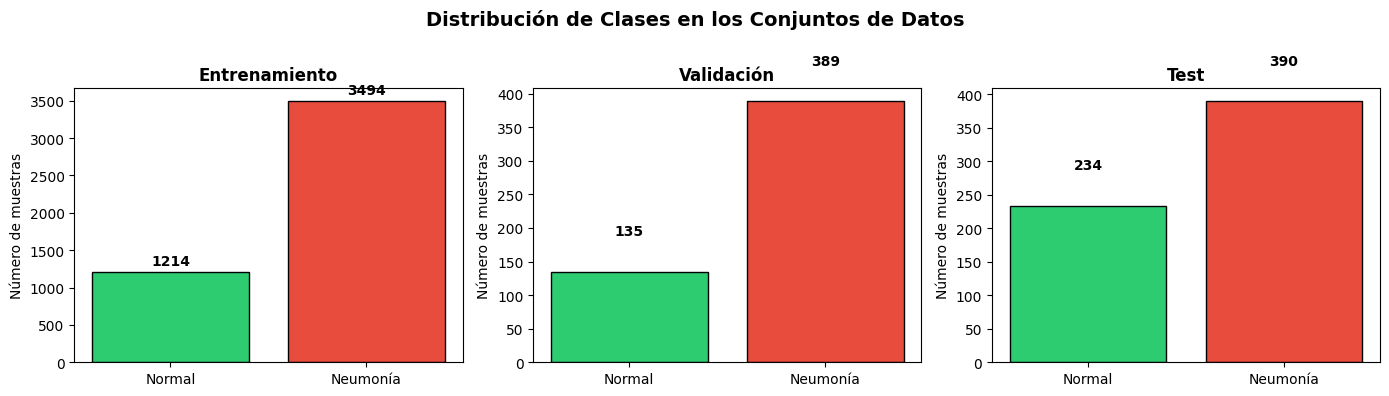


⚠️ OBSERVACIÓN: El dataset está DESBALANCEADO - hay más casos de neumonía que normales.
   Esto es importante considerarlo en el entrenamiento y evaluación del modelo.


In [49]:
# Visualización de la distribución de clases
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

conjuntos = ['Entrenamiento', 'Validación', 'Test']
distribuciones = [
    np.unique(y_train, return_counts=True)[1],
    np.unique(y_val, return_counts=True)[1],
    np.unique(y_test, return_counts=True)[1]
]
colores = ['#2ecc71', '#e74c3c']  # Verde para Normal, Rojo para Neumonía

for ax, nombre, dist in zip(axes, conjuntos, distribuciones):
    bars = ax.bar(['Normal', 'Neumonía'], dist, color=colores, edgecolor='black')
    ax.set_title(f'{nombre}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Número de muestras')
    
    # Añadir etiquetas en las barras
    for bar, count in zip(bars, dist):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Distribución de Clases en los Conjuntos de Datos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ OBSERVACIÓN: El dataset está DESBALANCEADO - hay más casos de neumonía que normales.")
print("   Esto es importante considerarlo en el entrenamiento y evaluación del modelo.")

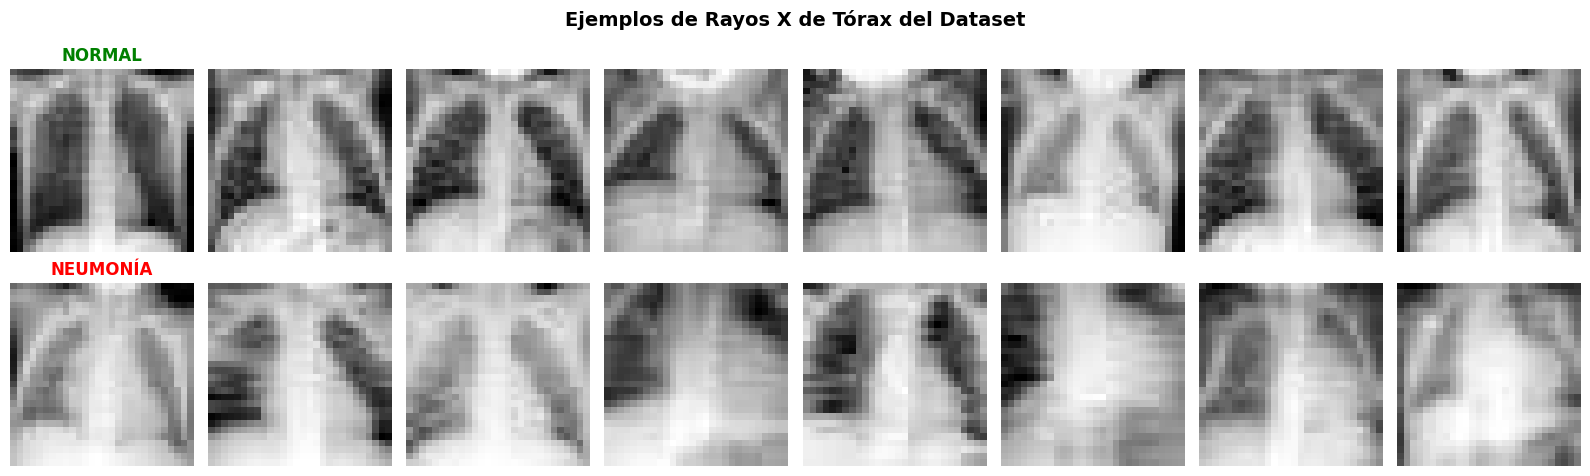

In [50]:
# Visualización de ejemplos de imágenes
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# Seleccionar ejemplos de cada clase
idx_normal = np.where(y_train.flatten() == 0)[0][:8]
idx_pneumonia = np.where(y_train.flatten() == 1)[0][:8]

# Mostrar imágenes normales (fila superior)
for i, idx in enumerate(idx_normal):
    axes[0, i].imshow(X_train[idx], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('NORMAL', fontsize=12, color='green', fontweight='bold')

# Mostrar imágenes con neumonía (fila inferior)
for i, idx in enumerate(idx_pneumonia):
    axes[1, i].imshow(X_train[idx], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('NEUMONÍA', fontsize=12, color='red', fontweight='bold')

plt.suptitle('Ejemplos de Rayos X de Tórax del Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ejemplos_imagenes.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# Análisis estadístico de las imágenes
print("=" * 60)
print("ESTADÍSTICAS DE LAS IMÁGENES")
print("=" * 60)
print(f"Tipo de datos: {X_train.dtype}")
print(f"Valor mínimo: {X_train.min()}")
print(f"Valor máximo: {X_train.max()}")
print(f"Media: {X_train.mean():.2f}")
print(f"Desviación estándar: {X_train.std():.2f}")

ESTADÍSTICAS DE LAS IMÁGENES
Tipo de datos: uint8
Valor mínimo: 0
Valor máximo: 255
Media: 145.84
Desviación estándar: 42.93


## 3. Preprocesamiento de datos 

In [52]:
# Normalización de las imágenes (de 0-255 a 0-1)
X_train_norm = X_train.astype('float32') / 255.0
X_val_norm = X_val.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Reshape para añadir la dimensión del canal (28, 28) -> (28, 28, 1)
# Las CNNs esperan tensores de 4 dimensiones: (batch, height, width, channels)
X_train_norm = X_train_norm.reshape(-1, 28, 28, 1)
X_val_norm = X_val_norm.reshape(-1, 28, 28, 1)
X_test_norm = X_test_norm.reshape(-1, 28, 28, 1)

# Aplanar las etiquetas
y_train_flat = y_train.flatten()
y_val_flat = y_val.flatten()
y_test_flat = y_test.flatten()

print("=" * 60)
print("DATOS DESPUÉS DEL PREPROCESAMIENTO")
print("=" * 60)
print(f"Shape X_train: {X_train_norm.shape}")
print(f"Shape X_val: {X_val_norm.shape}")
print(f"Shape X_test: {X_test_norm.shape}")
print(f"\nRango de valores: [{X_train_norm.min()}, {X_train_norm.max()}]")
print(f"Shape y_train: {y_train_flat.shape}")

DATOS DESPUÉS DEL PREPROCESAMIENTO
Shape X_train: (4708, 28, 28, 1)
Shape X_val: (524, 28, 28, 1)
Shape X_test: (624, 28, 28, 1)

Rango de valores: [0.0, 1.0]
Shape y_train: (4708,)


In [53]:
# Calcular pesos de clase para manejar el desbalanceo
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

class_weight_dict = dict(enumerate(class_weights))

print("=" * 60)
print("PESOS DE CLASE PARA BALANCEO")
print("=" * 60)
print(f"Peso clase 0 (Normal): {class_weight_dict[0]:.4f}")
print(f"Peso clase 1 (Neumonía): {class_weight_dict[1]:.4f}")
print("\nEstos pesos penalizan más los errores en la clase minoritaria.")

PESOS DE CLASE PARA BALANCEO
Peso clase 0 (Normal): 1.9390
Peso clase 1 (Neumonía): 0.6737

Estos pesos penalizan más los errores en la clase minoritaria.


In [54]:
# Data Augmentation para mejorar la generalización
# Solo aplicamos augmentation al conjunto de entrenamiento

datagen = ImageDataGenerator(
    rotation_range=15,          # Rotación aleatoria hasta 15 grados
    width_shift_range=0.1,      # Desplazamiento horizontal
    height_shift_range=0.1,     # Desplazamiento vertical
    zoom_range=0.1,             # Zoom aleatorio
    horizontal_flip=True,       # Volteo horizontal (válido para rayos X)
    fill_mode='nearest'         # Modo de relleno para píxeles nuevos
)

# Ajustar el generador a los datos de entrenamiento
datagen.fit(X_train_norm)

print("Data Augmentation configurado con las siguientes transformaciones:")
print("  - Rotación: ±15°")
print("  - Desplazamiento: ±10%")
print("  - Zoom: ±10%")
print("  - Volteo horizontal")

Data Augmentation configurado con las siguientes transformaciones:
  - Rotación: ±15°
  - Desplazamiento: ±10%
  - Zoom: ±10%
  - Volteo horizontal


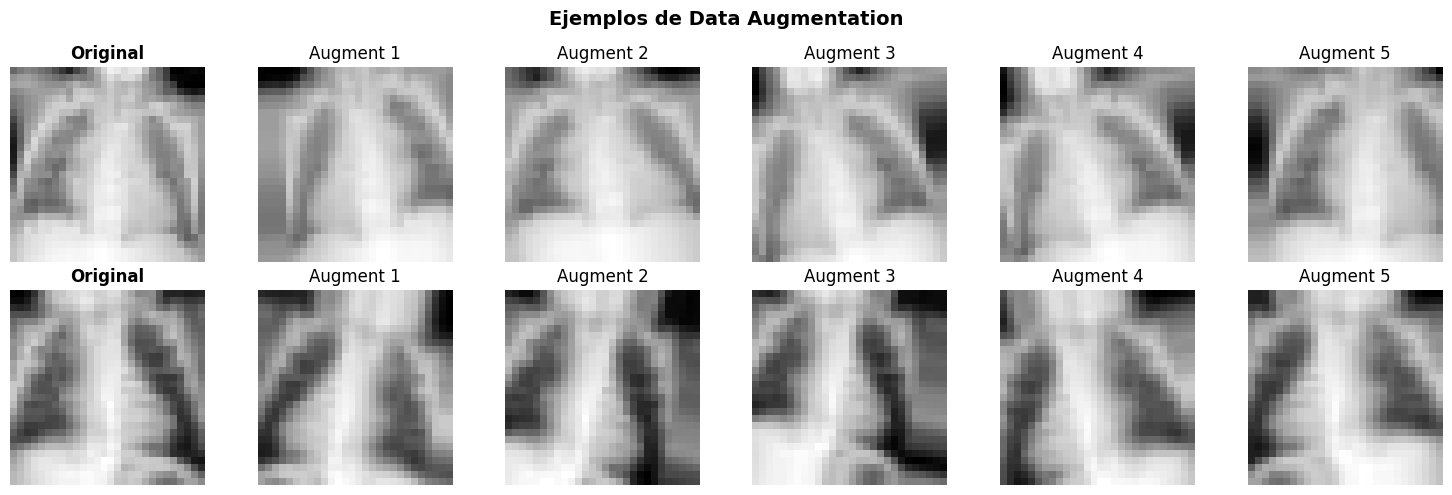

In [55]:
# Visualizar ejemplos de Data Augmentation
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Tomar una imagen de ejemplo
img_ejemplo = X_train_norm[0:1]

# Mostrar imagen original
axes[0, 0].imshow(img_ejemplo[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

# Generar y mostrar transformaciones
for i in range(1, 6):
    augmented = datagen.random_transform(img_ejemplo[0])
    axes[0, i].imshow(augmented[:, :, 0], cmap='gray')
    axes[0, i].set_title(f'Augment {i}')
    axes[0, i].axis('off')

# Segunda fila con otra imagen
img_ejemplo2 = X_train_norm[100:101]
axes[1, 0].imshow(img_ejemplo2[0, :, :, 0], cmap='gray')
axes[1, 0].set_title('Original', fontweight='bold')
axes[1, 0].axis('off')

for i in range(1, 6):
    augmented = datagen.random_transform(img_ejemplo2[0])
    axes[1, i].imshow(augmented[:, :, 0], cmap='gray')
    axes[1, i].set_title(f'Augment {i}')
    axes[1, i].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Creación del modelo CNN

In [56]:
def crear_modelo_cnn(input_shape=(28, 28, 1)):
    """
    Crea una CNN para clasificación binaria de imágenes de rayos X.
    
    Arquitectura:
    - 3 bloques convolucionales con BatchNorm y MaxPooling
    - Capas densas con Dropout para regularización
    - Salida sigmoidea para clasificación binaria
    """
    model = models.Sequential([
        # === BLOQUE CONVOLUCIONAL 1 ===
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # === BLOQUE CONVOLUCIONAL 2 ===
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # === BLOQUE CONVOLUCIONAL 3 ===
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # === CAPAS DENSAS (CLASIFICADOR) ===
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        # === CAPA DE SALIDA ===
        # Sigmoide para clasificación binaria
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Crear el modelo
modelo = crear_modelo_cnn()

# Mostrar resumen de la arquitectura
print("=" * 60)
print("ARQUITECTURA DEL MODELO CNN")
print("=" * 60)
modelo.summary()

ARQUITECTURA DEL MODELO CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             

 Total params: 617,953 (2.36 MB)

 Trainable params: 616,289 (2.35 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [57]:
# Compilar el modelo
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Para clasificación binaria
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),  # Área bajo la curva ROC
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("\n" + "=" * 60)
print("CONFIGURACIÓN DE COMPILACIÓN")
print("=" * 60)
print(f"Optimizador: Adam (lr=0.001)")
print(f"Función de pérdida: Binary Crossentropy")
print(f"Métricas: Accuracy, AUC, Precision, Recall")


CONFIGURACIÓN DE COMPILACIÓN
Optimizador: Adam (lr=0.001)
Función de pérdida: Binary Crossentropy
Métricas: Accuracy, AUC, Precision, Recall


In [58]:
# Visualizar la arquitectura del modelo
try:
    from tensorflow.keras.utils import plot_model
    plot_model(
        modelo, 
        to_file='arquitectura_modelo.png', 
        show_shapes=True, 
        show_layer_names=True,
        dpi=150
    )
    print("Diagrama de arquitectura guardado en 'arquitectura_modelo.png'")
except Exception as e:
    print(f"No se pudo generar el diagrama: {e}")

You must install pydot (`pip install pydot`) for `plot_model` to work.
Diagrama de arquitectura guardado en 'arquitectura_modelo.png'


## 5. Entrenamiento del Modelo




In [59]:
# Configuración de callbacks
callbacks_list = [
    # Detener si no hay mejora en val_loss por 10 épocas
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Guardar el mejor modelo basado en val_auc
    callbacks.ModelCheckpoint(
        'mejor_modelo_pneumonia.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Reducir learning rate si val_loss no mejora por 5 épocas
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurados:")
print("  1. EarlyStopping (patience=10)")
print("  2. ModelCheckpoint (guarda mejor modelo)")
print("  3. ReduceLROnPlateau (reduce lr si estanca)")

Callbacks configurados:
  1. EarlyStopping (patience=10)
  2. ModelCheckpoint (guarda mejor modelo)
  3. ReduceLROnPlateau (reduce lr si estanca)


In [60]:
# Hiperparámetros de entrenamiento
BATCH_SIZE = 32
EPOCHS = 50  # Máximo de épocas (EarlyStopping puede detener antes)

print("=" * 60)
print("INICIANDO ENTRENAMIENTO")
print("=" * 60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Épocas máximas: {EPOCHS}")
print(f"Usando pesos de clase: {class_weight_dict}")
print(f"Data Augmentation: Activado")
print("=" * 60 + "\n")

# Entrenar el modelo con Data Augmentation
historia = modelo.fit(
    datagen.flow(X_train_norm, y_train_flat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train_norm) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_norm, y_val_flat),
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

INICIANDO ENTRENAMIENTO
Batch size: 32
Épocas máximas: 50
Usando pesos de clase: {0: 1.9390444810543657, 1: 0.6737263880938752}
Data Augmentation: Activado

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7169 - auc: 0.8089 - loss: 0.5360 - precision: 0.9053 - recall: 0.6940
Epoch 1: val_auc improved from None to 0.50000, saving model to mejor_modelo_pneumonia.keras

Epoch 1: finished saving model to mejor_modelo_pneumonia.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 190ms/step - accuracy: 0.8084 - auc: 0.9072 - loss: 0.4018 - precision: 0.9428 - recall: 0.7894 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 1.7428 - val_precision: 0.7424 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
  1/147 ━━━━━━━━━━━━━━━━━━━━ 31s 218ms/step - accuracy: 0.8750 - auc: 0.9667 - loss: 0.3410 - precision: 1.0000 - recall: 0.8519
Epoch 2: val_auc did not improve from 0.50000
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8750 - auc: 0.9667 - loss: 0.3410 - precision: 1

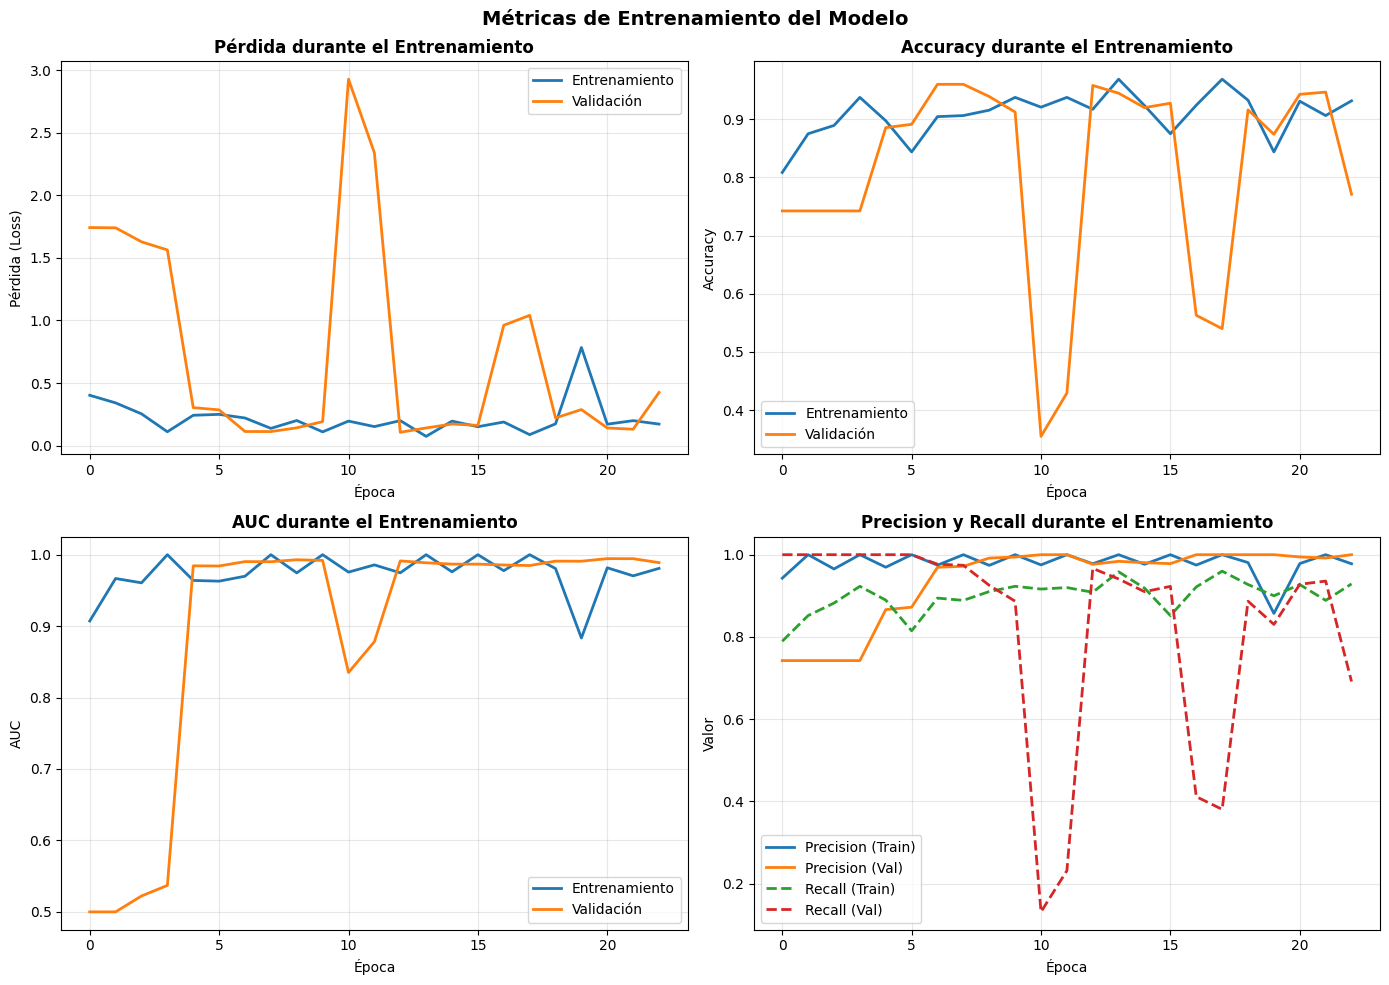

In [61]:
# Visualizar el historial de entrenamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Pérdida (Loss)
axes[0, 0].plot(historia.history['loss'], label='Entrenamiento', linewidth=2)
axes[0, 0].plot(historia.history['val_loss'], label='Validación', linewidth=2)
axes[0, 0].set_title('Pérdida durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida (Loss)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Accuracy
axes[0, 1].plot(historia.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[0, 1].plot(historia.history['val_accuracy'], label='Validación', linewidth=2)
axes[0, 1].set_title('Accuracy durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: AUC
axes[1, 0].plot(historia.history['auc'], label='Entrenamiento', linewidth=2)
axes[1, 0].plot(historia.history['val_auc'], label='Validación', linewidth=2)
axes[1, 0].set_title('AUC durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Precision y Recall
axes[1, 1].plot(historia.history['precision'], label='Precision (Train)', linewidth=2)
axes[1, 1].plot(historia.history['val_precision'], label='Precision (Val)', linewidth=2)
axes[1, 1].plot(historia.history['recall'], label='Recall (Train)', linewidth=2, linestyle='--')
axes[1, 1].plot(historia.history['val_recall'], label='Recall (Val)', linewidth=2, linestyle='--')
axes[1, 1].set_title('Precision y Recall durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Valor')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Métricas de Entrenamiento del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('historial_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación del modelo 

In [62]:
# Cargar el mejor modelo guardado
mejor_modelo = keras.models.load_model('mejor_modelo_pneumonia.keras')
print("Mejor modelo cargado desde 'mejor_modelo_pneumonia.keras'")

Mejor modelo cargado desde 'mejor_modelo_pneumonia.keras'


In [63]:
# Evaluar en el conjunto de test
print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

resultados = mejor_modelo.evaluate(X_test_norm, y_test_flat, verbose=0)

metricas_nombres = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
for nombre, valor in zip(metricas_nombres, resultados):
    print(f"{nombre}: {valor:.4f}")

EVALUACIÓN EN CONJUNTO DE TEST
Loss: 0.2159
Accuracy: 0.9183
AUC: 0.9739
Precision: 0.9084
Recall: 0.9667


In [64]:
# Obtener predicciones
y_pred_prob = mejor_modelo.predict(X_test_norm, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Predicciones generadas para el conjunto de test.")
print(f"Shape probabilidades: {y_pred_prob.shape}")
print(f"Shape predicciones: {y_pred.shape}")

Predicciones generadas para el conjunto de test.
Shape probabilidades: (624, 1)
Shape predicciones: (624,)


In [65]:
# Reporte de clasificación detallado
print("=" * 60)
print("REPORTE DE CLASIFICACIÓN")
print("=" * 60)
print(classification_report(
    y_test_flat, 
    y_pred, 
    target_names=['Normal (0)', 'Neumonía (1)']
))

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

  Normal (0)       0.94      0.84      0.88       234
Neumonía (1)       0.91      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



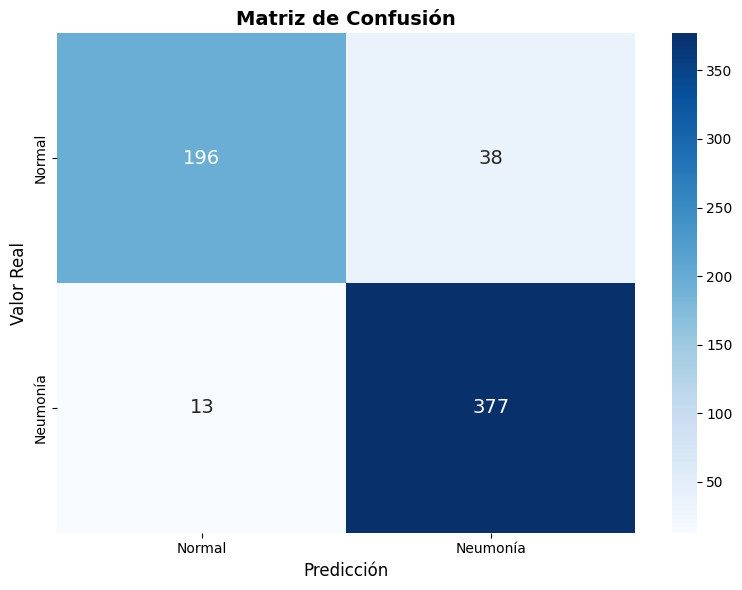


Interpretación de la Matriz de Confusión:
  - Verdaderos Negativos (TN): 196 - Normales correctamente identificados
  - Falsos Positivos (FP): 38 - Normales clasificados como neumonía
  - Falsos Negativos (FN): 13 - Neumonías no detectadas (CRÍTICO)
  - Verdaderos Positivos (TP): 377 - Neumonías correctamente detectadas


In [66]:
# Matriz de confusión
cm = confusion_matrix(y_test_flat, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Normal', 'Neumonía'],
    yticklabels=['Normal', 'Neumonía'],
    annot_kws={'size': 14}
)
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretar la matriz
tn, fp, fn, tp = cm.ravel()
print("\nInterpretación de la Matriz de Confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} - Normales correctamente identificados")
print(f"  - Falsos Positivos (FP): {fp} - Normales clasificados como neumonía")
print(f"  - Falsos Negativos (FN): {fn} - Neumonías no detectadas (CRÍTICO)")
print(f"  - Verdaderos Positivos (TP): {tp} - Neumonías correctamente detectadas")

## 7. Visualización de resultados 

In [67]:
# Identificar predicciones correctas e incorrectas
correctas = np.where(y_pred == y_test_flat)[0]
incorrectas = np.where(y_pred != y_test_flat)[0]

print(f"Predicciones correctas: {len(correctas)} ({len(correctas)/len(y_test_flat)*100:.1f}%)")
print(f"Predicciones incorrectas: {len(incorrectas)} ({len(incorrectas)/len(y_test_flat)*100:.1f}%)")

Predicciones correctas: 573 (91.8%)
Predicciones incorrectas: 51 (8.2%)


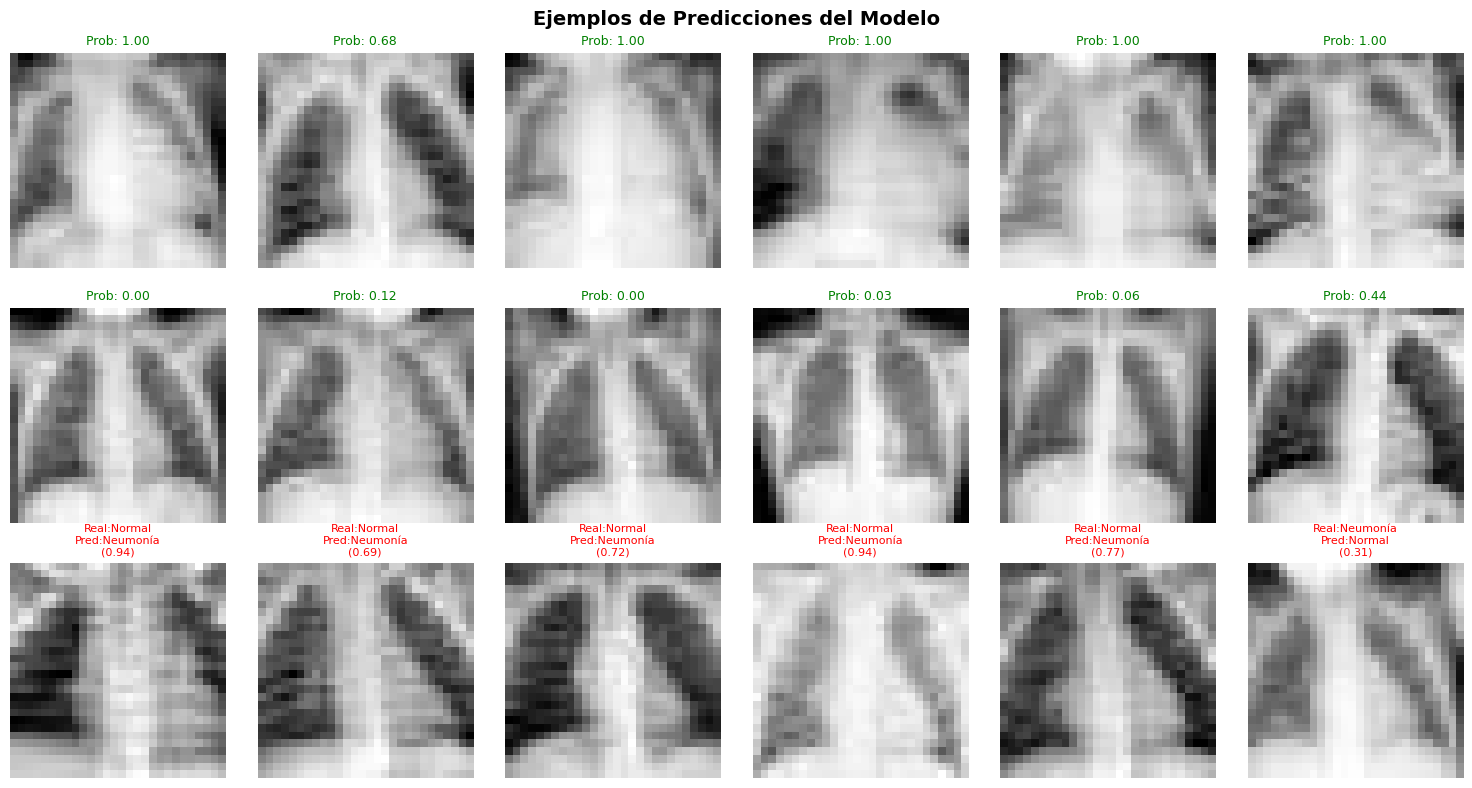

In [68]:
# Visualizar ejemplos de predicciones
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

etiquetas = {0: 'Normal', 1: 'Neumonía'}

# Fila 1: Verdaderos Positivos (Neumonía correctamente detectada)
tp_idx = np.where((y_pred == 1) & (y_test_flat == 1))[0][:6]
for i, idx in enumerate(tp_idx):
    axes[0, i].imshow(X_test_norm[idx, :, :, 0], cmap='gray')
    prob = y_pred_prob[idx][0]
    axes[0, i].set_title(f'Prob: {prob:.2f}', fontsize=9, color='green')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('VP\n(Neumonía\ndetectada)', fontsize=10, fontweight='bold')

# Fila 2: Verdaderos Negativos (Normal correctamente identificado)
tn_idx = np.where((y_pred == 0) & (y_test_flat == 0))[0][:6]
for i, idx in enumerate(tn_idx):
    axes[1, i].imshow(X_test_norm[idx, :, :, 0], cmap='gray')
    prob = y_pred_prob[idx][0]
    axes[1, i].set_title(f'Prob: {prob:.2f}', fontsize=9, color='green')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('VN\n(Normal\nidentificado)', fontsize=10, fontweight='bold')

# Fila 3: Errores (Falsos Positivos y Falsos Negativos)
if len(incorrectas) > 0:
    for i, idx in enumerate(incorrectas[:6]):
        axes[2, i].imshow(X_test_norm[idx, :, :, 0], cmap='gray')
        prob = y_pred_prob[idx][0]
        real = etiquetas[y_test_flat[idx]]
        pred = etiquetas[y_pred[idx]]
        axes[2, i].set_title(f'Real:{real}\nPred:{pred}\n({prob:.2f})', fontsize=8, color='red')
        axes[2, i].axis('off')
axes[2, 0].set_ylabel('ERRORES', fontsize=10, fontweight='bold', color='red')

plt.suptitle('Ejemplos de Predicciones del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ejemplos_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

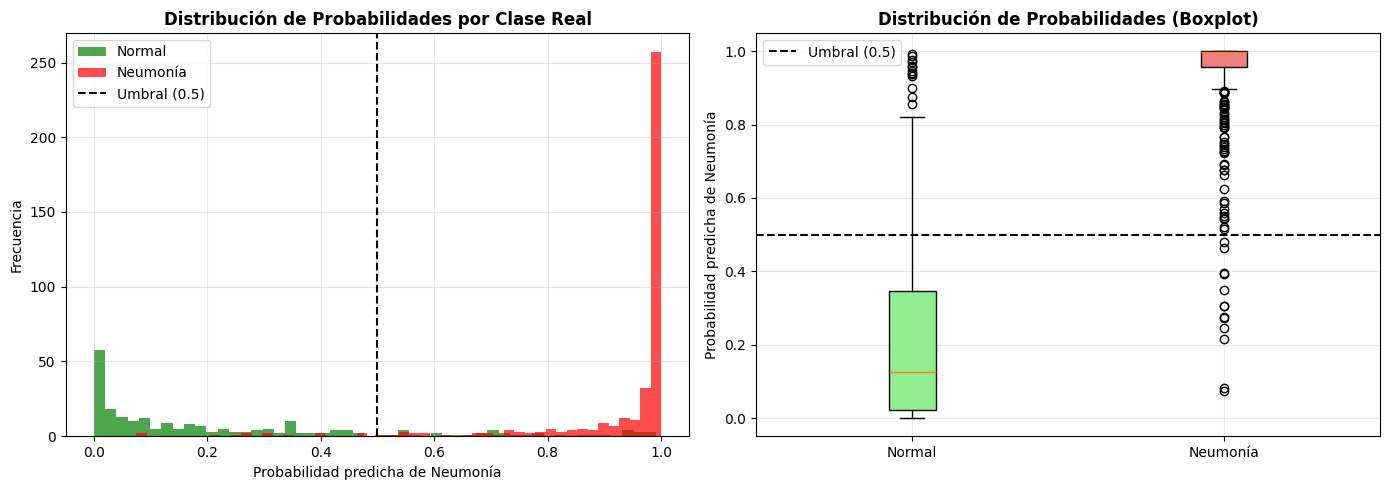

In [69]:
# Distribución de probabilidades predichas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades por clase real
axes[0].hist(y_pred_prob[y_test_flat == 0], bins=50, alpha=0.7, label='Normal', color='green')
axes[0].hist(y_pred_prob[y_test_flat == 1], bins=50, alpha=0.7, label='Neumonía', color='red')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Umbral (0.5)')
axes[0].set_xlabel('Probabilidad predicha de Neumonía')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Probabilidades por Clase Real', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot de probabilidades
data_box = [y_pred_prob[y_test_flat == 0].flatten(), y_pred_prob[y_test_flat == 1].flatten()]
bp = axes[1].boxplot(data_box, labels=['Normal', 'Neumonía'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].axhline(y=0.5, color='black', linestyle='--', label='Umbral (0.5)')
axes[1].set_ylabel('Probabilidad predicha de Neumonía')
axes[1].set_title('Distribución de Probabilidades (Boxplot)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribucion_probabilidades.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardando el modelo 

In [72]:
# Crear directorio para modelos si no existe

os.makedirs('modelos_guardados', exist_ok=True)

print("=" * 60)
print("GUARDANDO EL MODELO")
print("=" * 60)

#  Guardar en formato Keras 
ruta_keras = 'modelos_guardados/modelo_pneumonia.keras'
mejor_modelo.save(ruta_keras)
print(f" Modelo guardado en formato Keras: {ruta_keras}")

GUARDANDO EL MODELO
 Modelo guardado en formato Keras: modelos_guardados/modelo_pneumonia.keras
